# 02 — Visualize the ML-Ready GloFAS Cube

Loads the artifacts written by **`01_download_process.ipynb`** and sanity-checks them *before* any
modeling. Four checks:

1. **Manifest** — confirm window, region, shape, channels.
2. **Maps** — mean state of each channel (does the river network / wetness look right?).
3. **Time series** — domain-mean of each channel over the window (is the event visible?).
4. **Distributions** — raw vs standardized histograms (did normalization work?).

Run `01_download_process.ipynb` first so `data_ready/` exists.


In [13]:
# ============================================================
# CELL 1 — Locate & load the processed cube
# ============================================================
from pathlib import Path
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
PROC_DIR = Path("data_ready")

manifests = sorted(PROC_DIR.glob("glofas_*_manifest.json"))
assert manifests, "No processed data found — run 01_download_process.ipynb first."
manifest = json.load(open(manifests[-1]))          # most recent window
TAG = manifest["tag"]
print("loaded window:", TAG)
print(json.dumps(manifest, indent=2))

def open_nc(p):
    for eng in ("h5netcdf", "netcdf4", None):
        try:
            return xr.open_dataset(p, engine=eng) if eng else xr.open_dataset(p)
        except (ValueError, OSError):
            continue
    raise IOError(p)

raw  = open_nc(PROC_DIR / manifest["files"]["raw"])["glofas"]
norm = open_nc(PROC_DIR / manifest["files"]["norm"])["glofas"]
stats = json.load(open(PROC_DIR / f"glofas_{TAG}_stats.json"))
channels = manifest["channels"]


loaded window: bd_ne_india_2022-03_to_2022-07_d01-30
{
  "tag": "bd_ne_india_2022-03_to_2022-07_d01-30",
  "region": "bd_ne_india",
  "area_NWSE": [
    27.5,
    87.0,
    21.0,
    94.0
  ],
  "year": "2022",
  "months": [
    "03",
    "04",
    "05",
    "06",
    "07"
  ],
  "days": [
    "01",
    "30"
  ],
  "channels": [
    "discharge",
    "runoff",
    "soil_wetness"
  ],
  "shape_time_channel_lat_lon": [
    150,
    3,
    130,
    140
  ],
  "resolution_deg": 0.05,
  "time_step": "daily",
  "source": "GloFAS-ERA5 v4.0 (cems-glofas-historical, EWDS)",
  "citation": "Harrigan et al. (2020) ESSD; DOI 10.24381/cds.a4fdd6b9",
  "normalization": "per-channel standardize (mean 0 / std 1); see *_stats.json",
  "files": {
    "raw": "glofas_bd_ne_india_2022-03_to_2022-07_d01-30_raw.nc",
    "norm": "glofas_bd_ne_india_2022-03_to_2022-07_d01-30_norm.nc"
  }
}


## 1. Maps — mean state of each channel

One panel per channel, averaged over the window. Discharge uses a **log scale** (values span
orders of magnitude) so the river network shows; runoff and soil wetness use linear scales.
Sanity check: the discharge panel should look like a river network, SWI should be a smooth 0–1
field, runoff should highlight the wettest areas (e.g. the Meghalaya edge for a monsoon window).


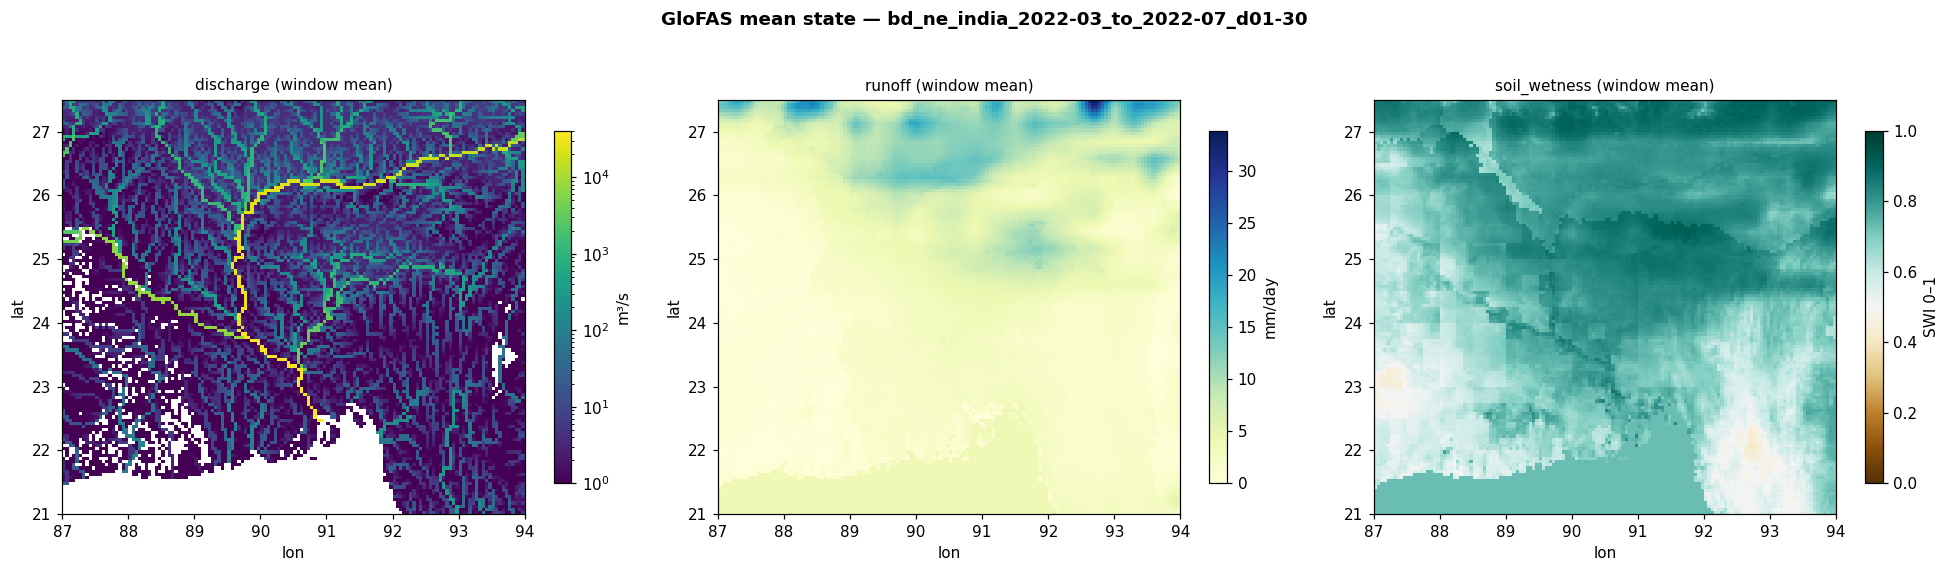

In [14]:
# ============================================================
# CELL 2 — Mean-state maps
# ============================================================
cfgs = {
    "discharge":    dict(cmap="viridis", log=True,  label="m³/s"),
    "runoff":       dict(cmap="YlGnBu",  log=False, label="mm/day"),
    "soil_wetness": dict(cmap="BrBG",    log=False, label="SWI 0–1", vmin=0, vmax=1),
}
fig, axes = plt.subplots(1, len(channels), figsize=(6 * len(channels), 5))
axes = np.atleast_1d(axes)
for ax, ch in zip(axes, channels):
    fld = raw.sel(channel=ch).mean("time")
    cf = cfgs.get(ch, dict(cmap="viridis", log=False, label=""))
    if cf.get("log"):
        im = ax.pcolormesh(fld.longitude, fld.latitude, fld.where(fld > 0.1),
                           norm=LogNorm(vmin=1, vmax=float(fld.max())), cmap=cf["cmap"], shading="auto")
    else:
        im = ax.pcolormesh(fld.longitude, fld.latitude, fld, cmap=cf["cmap"],
                           vmin=cf.get("vmin"), vmax=cf.get("vmax"), shading="auto")
    ax.set_title(f"{ch} (window mean)", fontsize=10)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, label=cf["label"], shrink=0.85)
fig.suptitle(f"GloFAS mean state — {TAG}", y=1.03, fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 1b. Monthly maps — see every month (not just the window mean)

The mean-state maps above collapse the whole window into one map per channel. When your window
spans **multiple months**, this grid shows **one map per month** instead (rows = channels,
columns = months), so you can watch the season evolve left-to-right. Works for any number of
months — with a 1-month window it's just a single column. Non-contiguous months (e.g. a gap)
simply appear as separate columns.

5 month(s): ['2022-03', '2022-04', '2022-05', '2022-06', '2022-07']


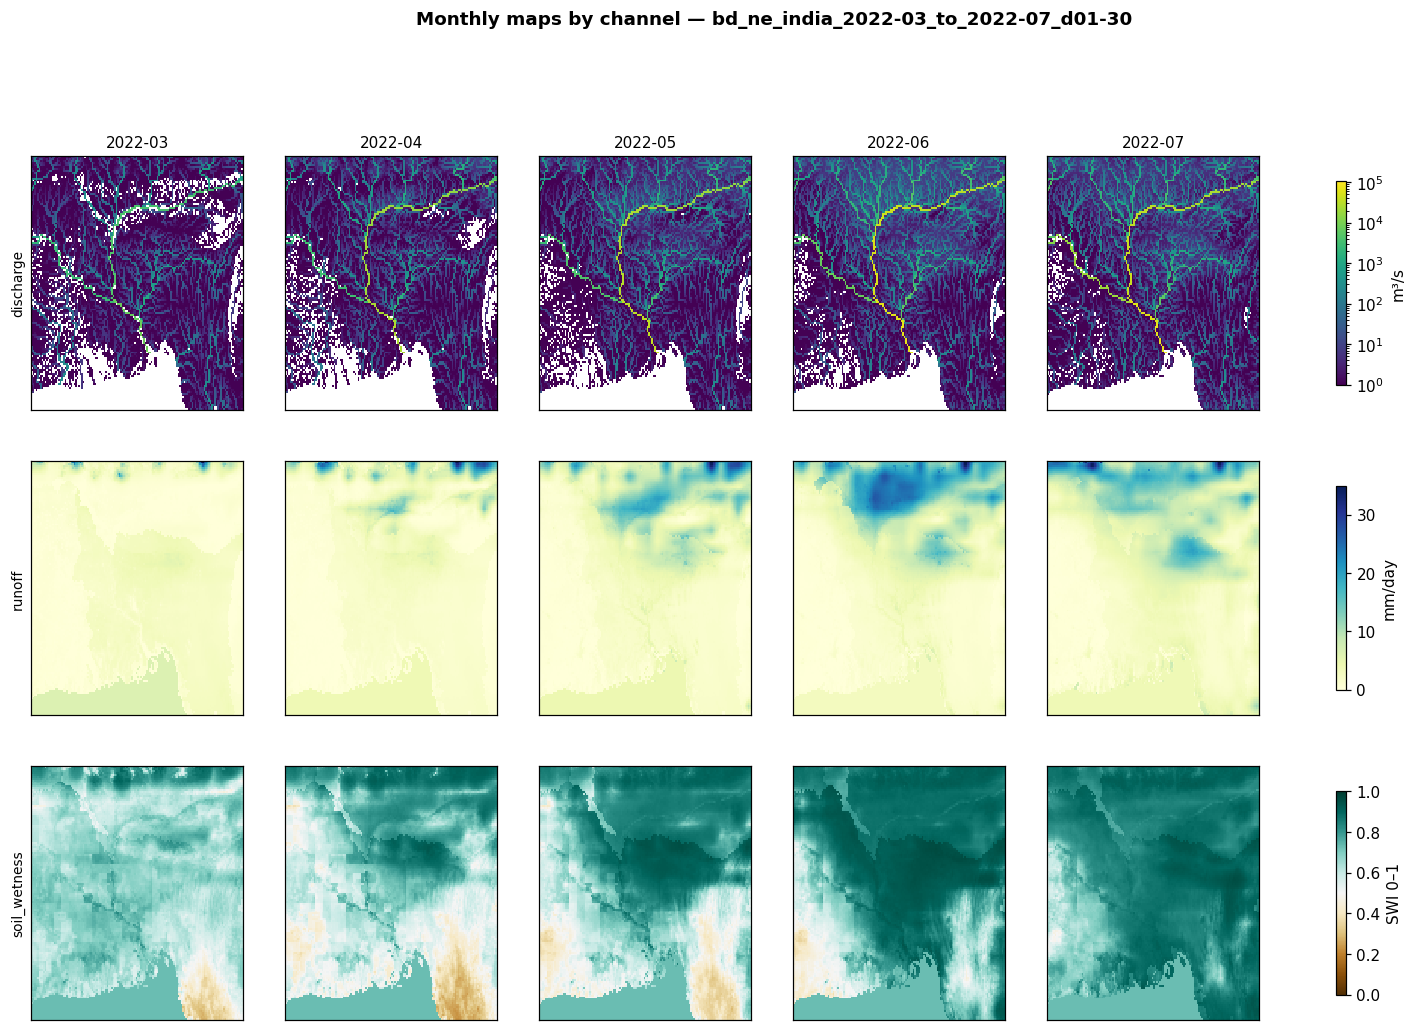

In [15]:
# ============================================================
# CELL 2b — Monthly map grid (channels x months)
# ============================================================
import pandas as pd

month_labels = pd.to_datetime(raw.time.values).strftime("%Y-%m")
raw_m   = raw.assign_coords(month=("time", month_labels))
monthly = {ch: raw_m.sel(channel=ch).groupby("month").mean("time") for ch in channels}
uniq_months = list(monthly[channels[0]].month.values)
print(f"{len(uniq_months)} month(s): {uniq_months}")

ncols = len(uniq_months)
fig, axes = plt.subplots(len(channels), ncols,
                         figsize=(3.6 * ncols, 3.4 * len(channels)), squeeze=False)
for r, ch in enumerate(channels):
    cf = cfgs.get(ch, dict(cmap="viridis", log=False, label=""))
    vmax = float(raw.sel(channel=ch).max())
    for cidx, m in enumerate(uniq_months):
        ax = axes[r][cidx]
        fld = monthly[ch].sel(month=m)
        if cf.get("log"):
            im = ax.pcolormesh(fld.longitude, fld.latitude, fld.where(fld > 0.1),
                               norm=LogNorm(vmin=1, vmax=vmax), cmap=cf["cmap"], shading="auto")
        else:
            im = ax.pcolormesh(fld.longitude, fld.latitude, fld, cmap=cf["cmap"],
                               vmin=cf.get("vmin"), vmax=cf.get("vmax"), shading="auto")
        if r == 0:
            ax.set_title(m, fontsize=10)
        if cidx == 0:
            ax.set_ylabel(ch, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=list(axes[r]), shrink=0.8, label=cf["label"])
fig.suptitle(f"Monthly maps by channel — {TAG}", y=1.01, fontsize=12, fontweight="bold")
plt.show()


## 2. Time series — domain mean per channel

The spatial average of each channel across the window. This is the quickest "is the signal here?"
check: for a flood window, soil wetness should rise/stay high, runoff should spike, and discharge
should follow. Each channel is on its own axis (different units).


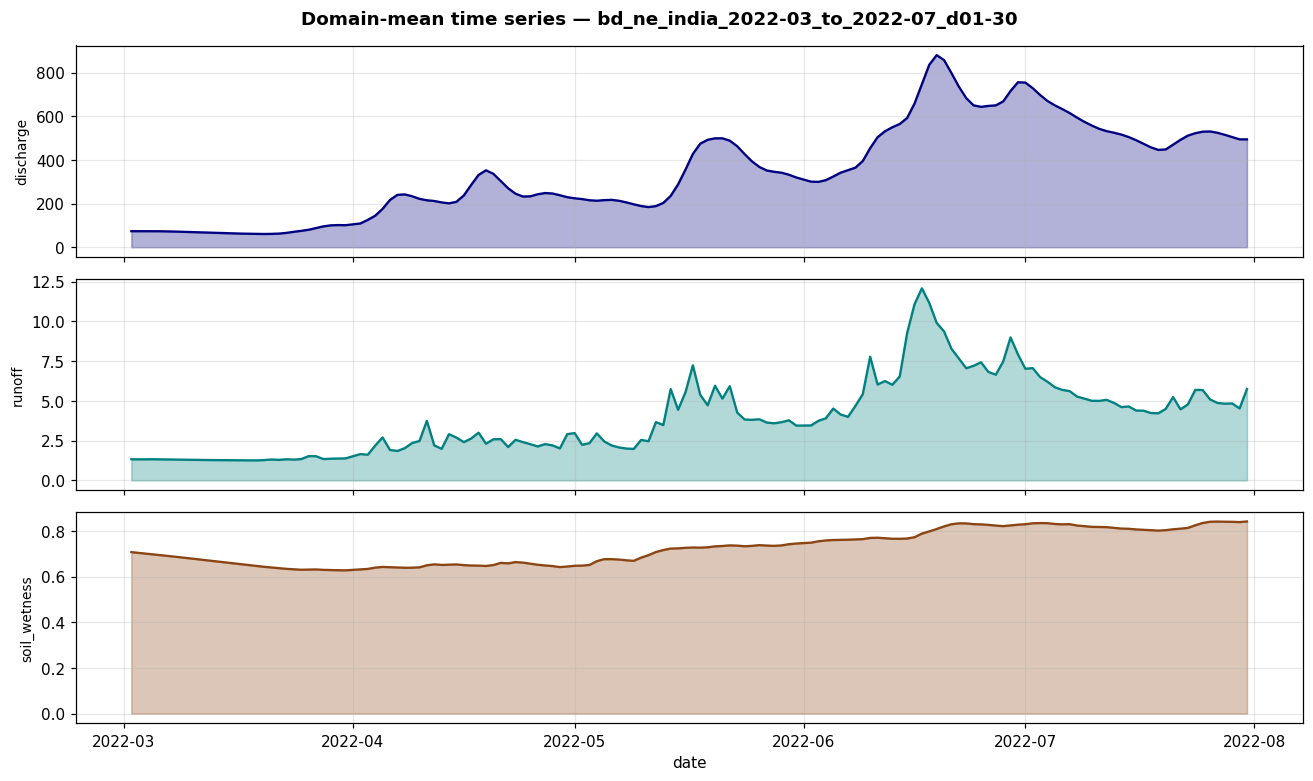

In [16]:
# ============================================================
# CELL 3 — Domain-mean time series
# ============================================================
fig, axes = plt.subplots(len(channels), 1, figsize=(12, 2.4 * len(channels)), sharex=True)
axes = np.atleast_1d(axes)
colors = {"discharge": "navy", "runoff": "teal", "soil_wetness": "saddlebrown"}
for ax, ch in zip(axes, channels):
    s = raw.sel(channel=ch).mean(("latitude", "longitude")).to_series()
    col = colors.get(ch, "gray")
    ax.fill_between(s.index, s.values, color=col, alpha=0.3)
    ax.plot(s.index, s.values, color=col, lw=1.5)
    ax.set_ylabel(ch, fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("date")
fig.suptitle(f"Domain-mean time series — {TAG}", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 3. Distributions — did normalization work?

For each channel: the **raw** histogram (physical units) and the **standardized** histogram (the
ML input). The standardized one should be centered near 0 with spread ~1. This confirms the
`*_stats.json` values are correct and the cube is genuinely model-ready.


discharge      raw[min=0.00, max=104540.28] norm[mean=-0.000, std=1.003]  (stats: {'mean': 350.3950500488281, 'std': 3393.246337890625})
runoff         raw[min=0.00, max=222.75] norm[mean=-0.000, std=1.000]  (stats: {'mean': 3.943751573562622, 'std': 6.372469902038574})
soil_wetness   raw[min=0.21, max=0.99] norm[mean=-0.000, std=1.000]  (stats: {'mean': 0.7275511026382446, 'std': 0.14877949655056})


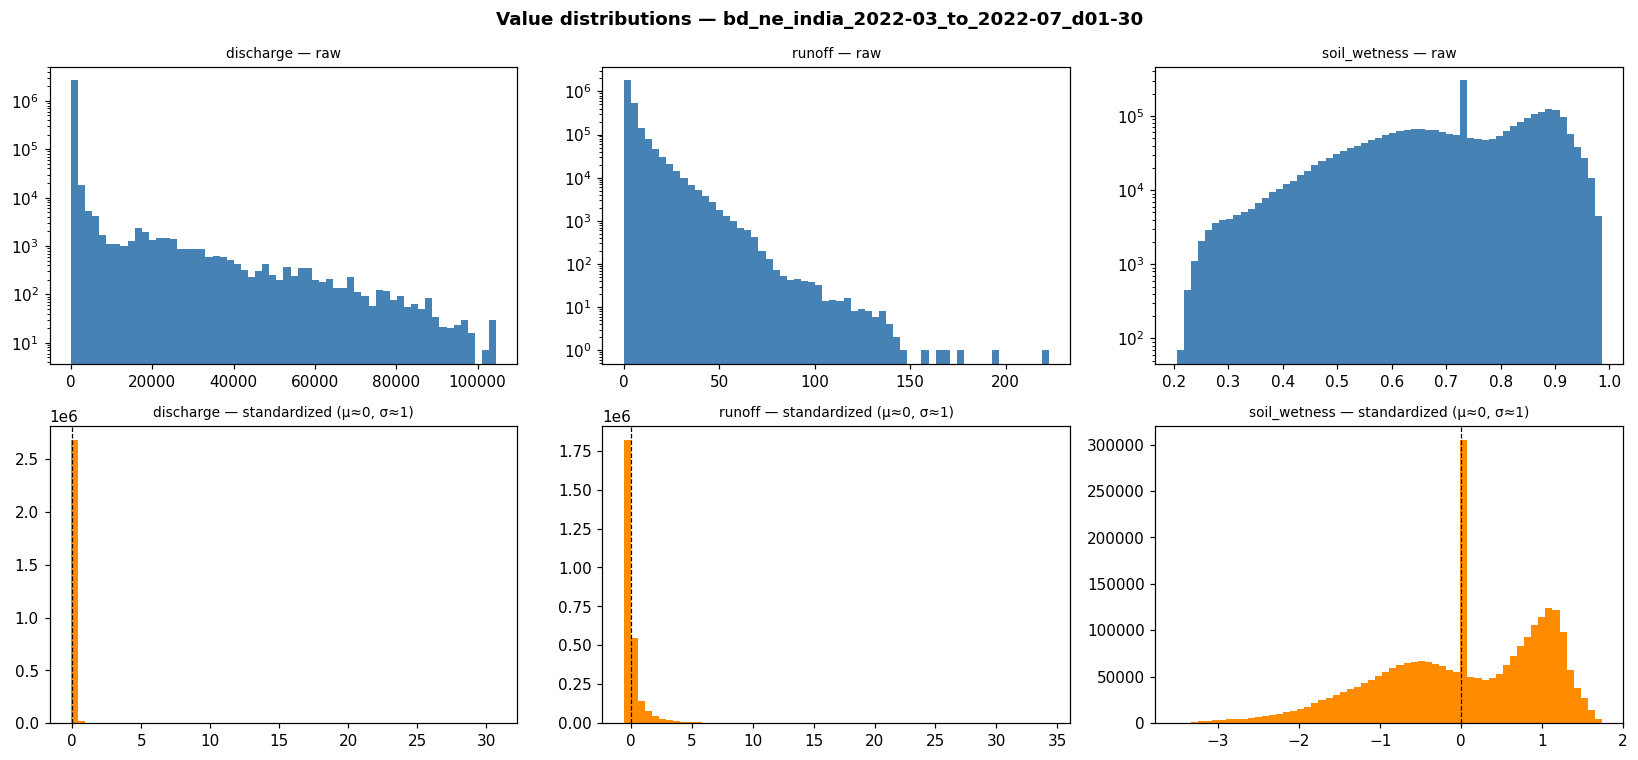

In [17]:
# ============================================================
# CELL 4 — Raw vs standardized histograms
# ============================================================
fig, axes = plt.subplots(2, len(channels), figsize=(5 * len(channels), 7))
axes = np.atleast_2d(axes)
for j, ch in enumerate(channels):
    r = raw.sel(channel=ch).values.ravel()
    n = norm.sel(channel=ch).values.ravel()
    r = r[np.isfinite(r)]; n = n[np.isfinite(n)]
    axes[0][j].hist(r, bins=60, color="steelblue")
    axes[0][j].set_title(f"{ch} — raw", fontsize=9)
    axes[0][j].set_yscale("log")
    axes[1][j].hist(n, bins=60, color="darkorange")
    axes[1][j].set_title(f"{ch} — standardized (μ≈0, σ≈1)", fontsize=9)
    axes[1][j].axvline(0, color="k", lw=0.8, ls="--")
    print(f"{ch:14s} raw[min={r.min():.2f}, max={r.max():.2f}] "
          f"norm[mean={n.mean():+.3f}, std={n.std():.3f}]  (stats: {stats[ch]})")
fig.suptitle(f"Value distributions — {TAG}", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## Summary

If the maps look like rivers/wetness, the time series shows the event, and the standardized
histograms are centered at 0 with spread ~1 — the cube in `data_ready/` is **ready for modeling**.

The array you feed a model is `norm` with shape `(time, channel, lat, lon)` =
`see manifest`. Batch it over samples/windows to get the
`(batch, time, channel, lat, lon)` tensor the MC-LSTM / CFM expects. Train/test split and the
model come in a later notebook.
